# Wine Dataset - Exploratory Data Analysis (EDA)

## Goal
Understand the structure of the Wine Dataset before preprocessing and modeling.
The target variable is **Price**. The key feature of interest is **Description** (free text).

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load & Inspect Dataset

In [28]:
# Load dataset
df = pd.read_csv('../../data/raw/WineDataset.csv')

# Basic info
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (1290, 17)

Columns: ['Title', 'Description', 'Price', 'Capacity', 'Grape', 'Secondary Grape Varieties', 'Closure', 'Country', 'Unit', 'Characteristics', 'Per bottle / case / each', 'Type', 'ABV', 'Region', 'Style', 'Vintage', 'Appellation']

Data types:
Title                            str
Description                      str
Price                            str
Capacity                         str
Grape                            str
Secondary Grape Varieties        str
Closure                          str
Country                          str
Unit                         float64
Characteristics                  str
Per bottle / case / each         str
Type                             str
ABV                              str
Region                           str
Style                            str
Vintage                          str
Appellation                      str
dtype: object

First 3 rows:


,Title,Description,Price,Capacity,Grape,Secondary Grape Varieties,Closure,Country,Unit,Characteristics,Per bottle / case / each,Type,ABV,Region,Style,Vintage,Appellation
0,"The Guv'nor, Spain",We asked some of our most prized winemakers wo...,£9.99 per bottle,75CL,Tempranillo,NaN,Natural Cork,Spain,10.5,"Vanilla, Blackberry, Blackcurrant",per bottle,Red,ABV 14.00%,NaN,Rich & Juicy,NV,NaN
1,Bread & Butter 'Winemaker's Selection' Chardon...,This really does what it says on the tin. It’s...,£15.99 per bottle,75CL,Chardonnay,NaN,Natural Cork,USA,10.1,"Vanilla, Almond, Coconut, Green Apple, Peach, ...",per bottle,White,ABV 13.50%,California,Rich & Toasty,2021,Napa Valley
2,"Oyster Bay Sauvignon Blanc 2022, Marlborough",Oyster Bay has been an award-winning gold-stan...,£12.49 per bottle,75CL,Sauvignon Blanc,NaN,Screwcap,New Zealand,9.8,"Tropical Fruit, Gooseberry, Grapefruit, Grass,...",per bottle,White,ABV 13.00%,Marlborough,Crisp & Zesty,2022,NaN


## 2. Missing Values

In [29]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df)

                           Missing Count  Missing %
Secondary Grape Varieties            802      62.17
Appellation                          646      50.08
Region                               166      12.87
Style                                 78       6.05
Characteristics                       37       2.87
Grape                                 15       1.16
Closure                               11       0.85
ABV                                    9       0.70
Unit                                   9       0.70
Vintage                                7       0.54
Country                                6       0.47
Type                                   5       0.39
Description                            4       0.31
Title                                  0       0.00
Capacity                               0       0.00
Price                                  0       0.00
Per bottle / case / each               0       0.00


### Observations
- Dataset has **1290 rows** and **17 columns**
- **Price** is stored as a string (e.g. "£9.99 per bottle") → needs cleaning
- **Secondary Grape Varieties** has 62% missing values → will likely be dropped
- **Appellation** has 50% missing values → will likely be dropped
- **Description** has only 4 missing values (0.31%) → good, almost complete
- **Region**, **Style** have moderate missing values → need strategy

## 3. Target Variable: Price
Price is stored as a string (e.g. "£9.99 per bottle") — we need to extract the numeric value before any modeling.

In [30]:
# Preview raw price values
print("Sample raw price values:")
print(df['Price'].value_counts().head(10))

# Extract numeric price
df['Price_clean'] = df['Price'].str.extract(r'£([\d.]+)').astype(float)

print(f"\nPrice statistics after cleaning:")
print(df['Price_clean'].describe())

Sample raw price values:
Price
£11.99 per bottle    100
£14.99 per bottle     96
£9.99 per bottle      91
£13.99 per bottle     77
£16.99 per bottle     67
£15.99 per bottle     58
£12.99 per bottle     58
£19.99 per bottle     49
£17.99 per bottle     48
£29.99 per bottle     47
Name: count, dtype: int64

Price statistics after cleaning:
count    1290.00000
mean       28.58569
std        35.54388
min         4.99000
25%        12.99000
50%        16.99000
75%        29.99000
max       430.00000
Name: Price_clean, dtype: float64


### Observations
- Price ranges from **£4.99** to **£430.00**
- Mean price is **£28.58** but median is only **£16.99** → distribution is right-skewed
- Most wines are affordable (75% cost under £30)
- Standard deviation is **£35.54** → high variance, driven by expensive outliers
- This skewness suggests we should apply a **log-transform** to Price before modeling

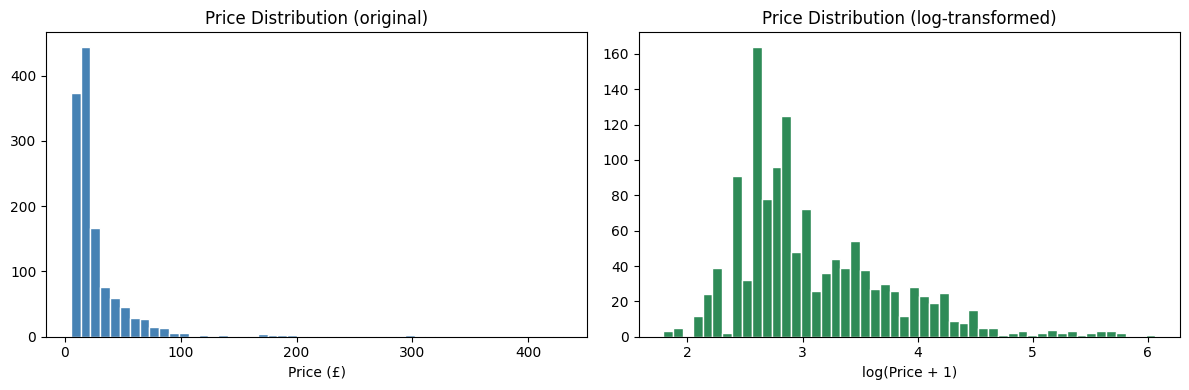

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original price distribution
axes[0].hist(df['Price_clean'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (original)')
axes[0].set_xlabel('Price (£)')

# Log-transformed price distribution
axes[1].hist(np.log1p(df['Price_clean'].dropna()), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Price Distribution (log-transformed)')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

### Observations
- The original price distribution is **strongly right-skewed** — most wines are cheap, 
  a few are very expensive (up to £430)
- After log-transform, the distribution becomes **much more normal-like**
- This confirms we should use **log-transformed Price** as target variable during modeling
- We will predict log(Price+1) and convert back with exp()-1 for interpretation

## 4. Description Column Analysis
The Description column is the key text feature. We analyze its completeness and length.

Missing descriptions: 4

Description word count stats:
count    1286.000000
mean       86.383359
std        30.229112
min        15.000000
25%        65.000000
50%        84.000000
75%       106.000000
max       212.000000
Name: desc_length, dtype: float64


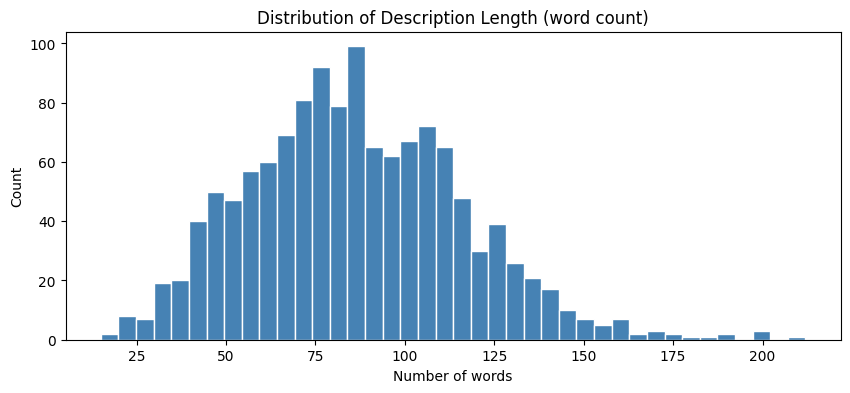

In [32]:
# Description length analysis
df['desc_length'] = df['Description'].dropna().apply(lambda x: len(x.split()))

print(f"Missing descriptions: {df['Description'].isnull().sum()}")
print(f"\nDescription word count stats:")
print(df['desc_length'].describe())

# Distribution of description lengths
plt.figure(figsize=(10, 4))
plt.hist(df['desc_length'].dropna(), bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Description Length (word count)')
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.show()

### Observations
- Only **4 missing descriptions** (0.31%) → excellent, almost complete
- Average description length is **86 words** — quite rich in text
- Range: **15 to 212 words** — good variation
- Distribution is **roughly normal** → no extreme outliers in text length
- The descriptions are long enough to contain meaningful semantic information 
  for TF-IDF and embeddings to exploit

## 5. Categorical Features Overview

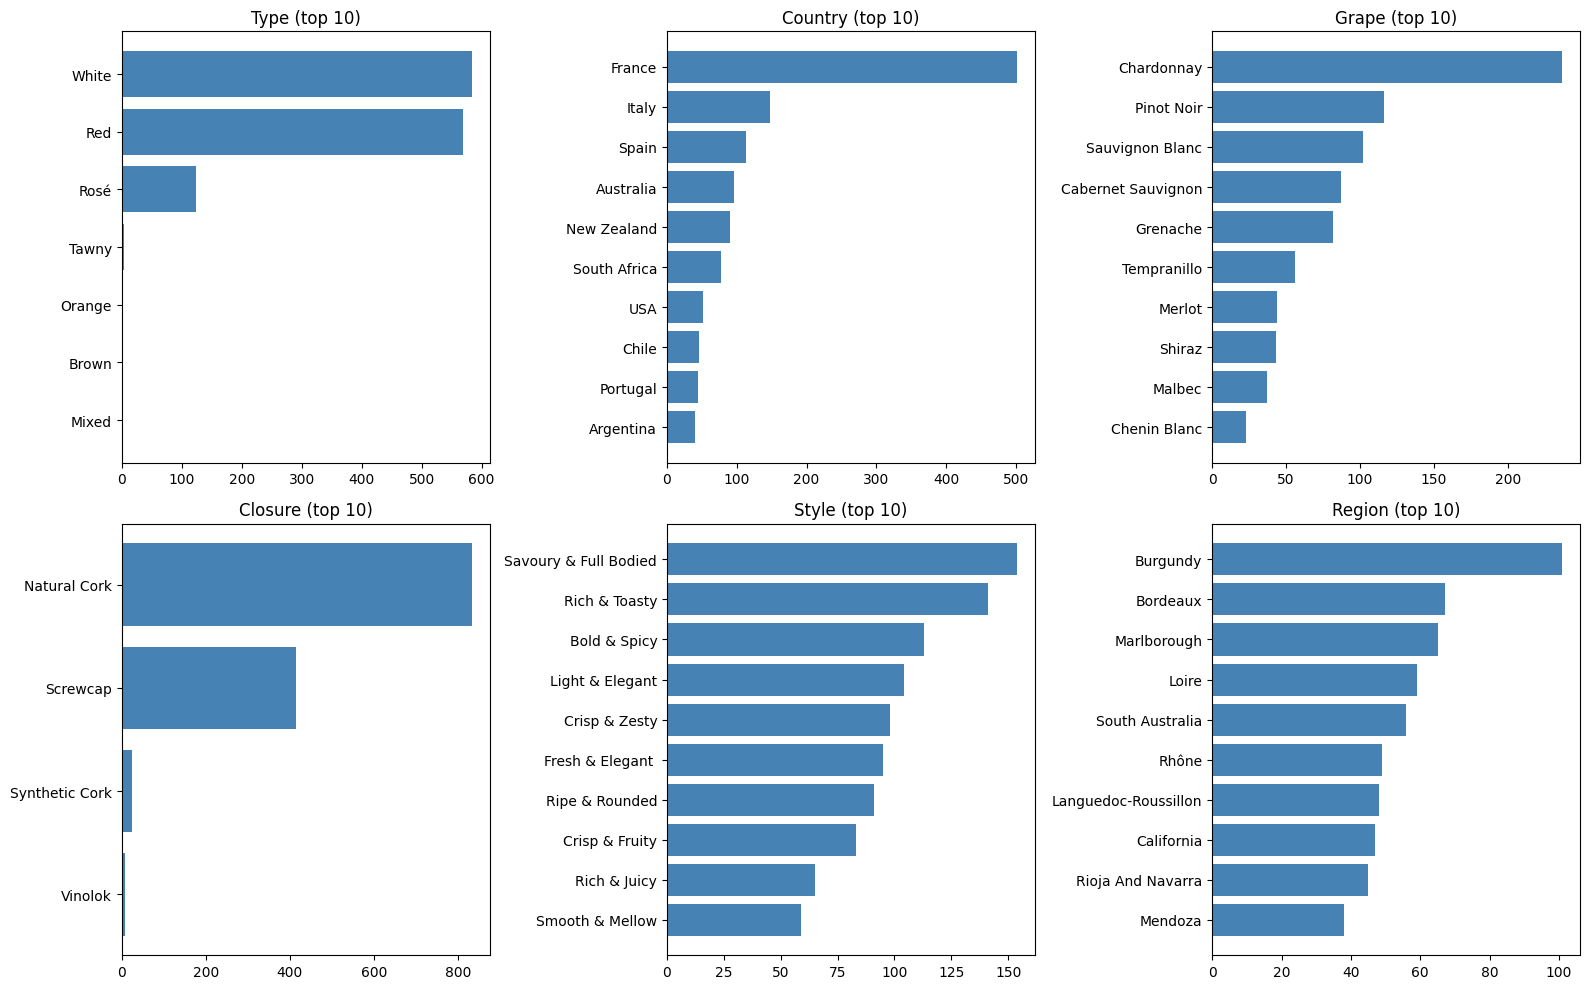

In [33]:
cat_cols = ['Type', 'Country', 'Grape', 'Closure', 'Style', 'Region']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top10 = df[col].value_counts().head(10)
    axes[i].barh(top10.index, top10.values, color='steelblue')
    axes[i].set_title(f'{col} (top 10)')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

### Observations
- **Type**: Dominated by White and Red wines — Rosé, Tawny, Orange are minority classes
- **Country**: France dominates strongly, followed by Italy and Spain — dataset is very Europe-centric
- **Grape**: Chardonnay is by far the most common grape, followed by Pinot Noir and Sauvignon Blanc
- **Closure**: Natural Cork is dominant (800+), Screwcap second — Synthetic Cork and Vinolok are rare
- **Style**: Good variety of styles, relatively balanced distribution
- **Region**: Burgundy and Bordeaux dominate — consistent with France being the top country

### Implications for modeling
- High-cardinality columns (Region, Grape, Country) will need careful encoding
- Some categories are very rare → risk of overfitting with One-Hot Encoding
- Columns like **Closure** and **Per bottle / case / each** may have low predictive value

## 6. EDA Summary & Next Steps

### Key findings
- 1290 rows, 17 columns
- Price needs cleaning (string → float) and log-transformation
- Secondary Grape Varieties (62%) and Appellation (50%) have too many missing values → will be dropped
- Description is almost complete (4 missing) and rich (avg 86 words) → key feature
- Several categorical columns with high cardinality → One-Hot Encoding with care

### Next steps
- **Preprocessing notebook**: clean Price, drop high-missing columns, encode categoricals, handle missing values
- **Baseline model**: TF-IDF on Description + Random Forest → evaluate performance
- **Improved model**: sentence embeddings on Description + Random Forest → compare with baseline